In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import zipfile
import os

print("Downloading dataset...")
url = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"
zip_path = "online_retail.zip"
urllib.request.urlretrieve(url, zip_path)

print("Extracting dataset...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("online_retail_data")

excel_file = [f for f in os.listdir("online_retail_data") if f.endswith('.xlsx')][0]
df_path = os.path.join("online_retail_data", excel_file)

print("Loading dataset...")
df = pd.read_excel(df_path)
print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

Extracting dataset...
Loading dataset...
Dataset loaded with 541909 rows and 8 columns.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import plotly.express as px

df_clean = df.dropna(subset=['CustomerID']).copy()
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']
ref_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (ref_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum',
    'Quantity': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'TotalQuantity']
rfm['AvgTransactionValue'] = rfm['Monetary'] / rfm['Frequency']

rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].apply(np.log1p, axis=1)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

print("RFM features constructed and standardized. Sample data:")
print(rfm.head())

RFM features constructed and standardized. Sample data:
   CustomerID  Recency  Frequency  Monetary  TotalQuantity  \
0     12346.0      326          1  77183.60          74215   
1     12347.0        2          7   4310.00           2458   
2     12348.0       75          4   1797.24           2341   
3     12349.0       19          1   1757.55            631   
4     12350.0      310          1    334.40            197   

   AvgTransactionValue  
0         77183.600000  
1           615.714286  
2           449.310000  
3          1757.550000  
4           334.400000  


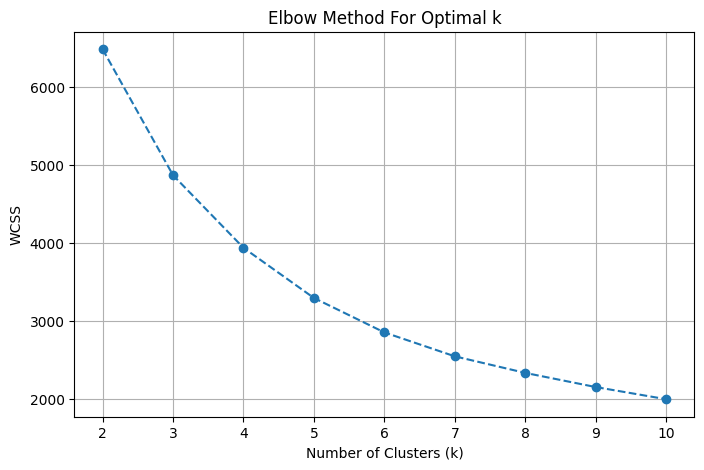

In [3]:
wcss = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [4]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

sil_score = silhouette_score(rfm_scaled, rfm['Cluster'])
print(f"Silhouette Score for k={optimal_k}: {sil_score:.4f}")

Silhouette Score for k=3: 0.3365


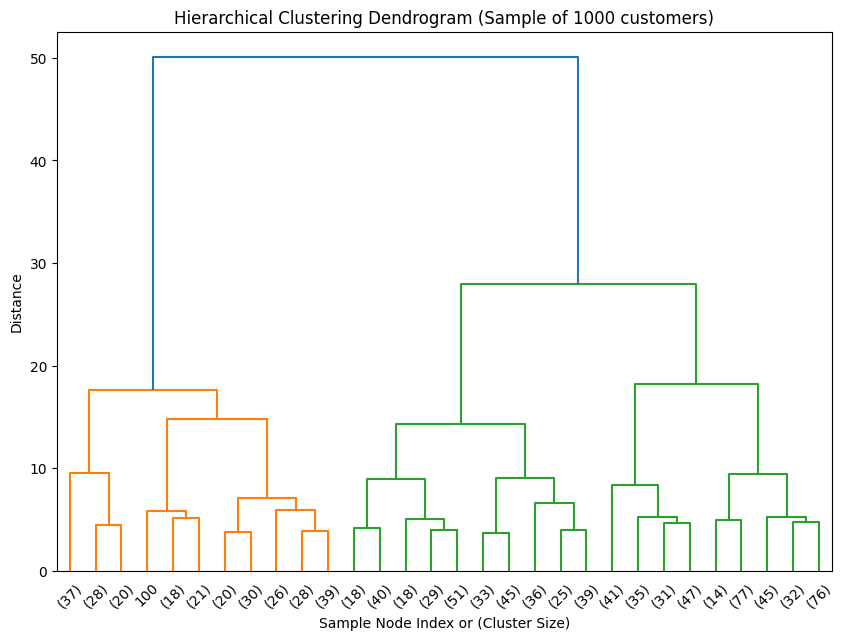

In [5]:
plt.figure(figsize=(10, 7))
plt.title("Hierarchical Clustering Dendrogram (Sample of 1000 customers)")
sample_indices = np.random.choice(rfm_scaled.shape[0], 1000, replace=False)
linkage_matrix = linkage(rfm_scaled[sample_indices], method='ward')
dendrogram(linkage_matrix, truncate_mode='lastp', p=30)
plt.xlabel("Sample Node Index or (Cluster Size)")
plt.ylabel("Distance")
plt.show()

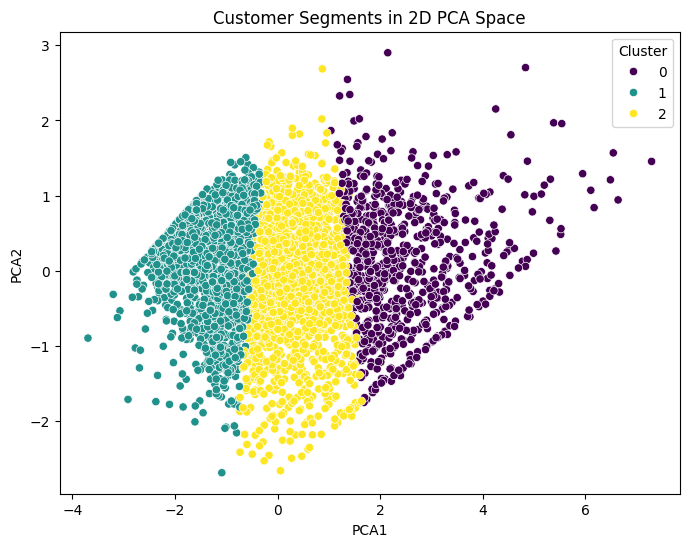

In [6]:
pca = PCA(n_components=3)
pca_transformed = pca.fit_transform(rfm_scaled)
rfm['PCA1'] = pca_transformed[:, 0]
rfm['PCA2'] = pca_transformed[:, 1]
rfm['PCA3'] = pca_transformed[:, 2]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=rfm, x='PCA1', y='PCA2', hue='Cluster', palette='viridis')
plt.title('Customer Segments in 2D PCA Space')
plt.show()

fig = px.scatter_3d(rfm, x='PCA1', y='PCA2', z='PCA3', color=rfm['Cluster'].astype(str),
                     title='3D Interactive Customer Segments', labels={'color': 'Cluster'})
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
print("Cluster Profiles:")
print(profile)

high_value_cluster = profile['Monetary'].idxmax()
rfm['Is_High_Value'] = (rfm['Cluster'] == high_value_cluster).astype(int)

X = rfm_scaled
y = rfm['Is_High_Value']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

svm_clf = SVC(probability=True, random_state=42)
svm_clf.fit(X_train, y_train)
y_pred_svm = svm_clf.predict(X_test)

print("\n--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, rf_clf.predict_proba(X_test)[:, 1]))

print("\n--- SVM Classification Report ---")
print(classification_report(y_test, y_pred_svm))
print("ROC-AUC Score:", roc_auc_score(y_test, svm_clf.predict_proba(X_test)[:, 1]))

Cluster Profiles:
            Recency  Frequency     Monetary
Cluster                                    
0         17.063636  13.338961  7905.440519
1        167.361111   1.352030   362.537613
2         44.212264   3.378538  1265.063852

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       714
           1       0.99      0.93      0.96       154

    accuracy                           0.99       868
   macro avg       0.99      0.96      0.97       868
weighted avg       0.99      0.99      0.98       868

ROC-AUC Score: 0.9993588344428681

--- SVM Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       714
           1       1.00      0.98      0.99       154

    accuracy                           1.00       868
   macro avg       1.00      0.99      0.99       868
weighted avg       1.00      1.00      1.00      

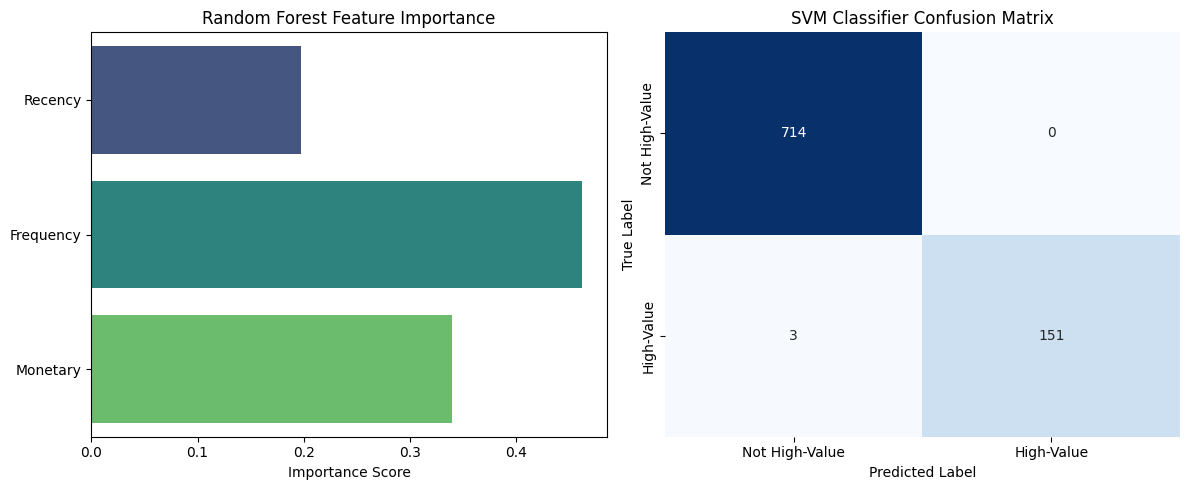

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

importances = rf_clf.feature_importances_
feature_names = ['Recency', 'Frequency', 'Monetary']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x=importances, y=feature_names, palette='viridis', hue=feature_names, legend=False)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')

plt.subplot(1, 2, 2)
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not High-Value', 'High-Value'],
            yticklabels=['Not High-Value', 'High-Value'])
plt.title('SVM Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

### 8. Segment-Wise Targeted Marketing Recommendations

Based on our RFM clustering, we recommend the following customized marketing campaigns:

* **Cluster 0 (High-Value "Champions")**:
  - *Strategy*: VIP Programs, early access to new collections, and referral rewards.
  - *Action*: Focus on loyalty retention and upselling premium packages. Avoid over-discounting as their engagement is already peak.

* **Cluster 2 (Loyal / Developing "Mid-tier")**:
  - *Strategy*: Upselling via product recommendation algorithms (Collaborative filtering) and milestone-based reward points.
  - *Action*: Offer cross-selling bundles to increase their overall basket size and transition them into the High-Value bracket.

* **Cluster 1 (At Risk / Lost)**:
  - *Strategy*: Win-back email campaigns, limited-time major clearance promotions, and satisfaction surveys.
  - *Action*: Trigger personalized email incentives to re-engage them before they churn completely.